# TASK 5 - Sales Prediction

## Problem Statement
**Sales prediction involves estimating how much of a product will be sold based on various factors such as advertising expenditure, target audience, and advertising platforms. The objective of this project is to build a machine learning model that can accurately predict sales based on advertising data using regression techniques.**

**STEPS**
- Load dataset
- Clean and preprocess data
- Perform exploratory data analysis (EDA)
- Analyze relationships between features (correlation analysis)
- Select important features (TV, Radio, Newspaper)
- Split data into training and testing sets
- Apply feature scaling (optional for Linear Regression)
- Train regression model (Linear Regression / Random Forest)
- Evaluate model performance (R² Score, MAE, MSE)
- Visualize results (Actual vs Predicted sales, regression plots)

## Import Libraries

In [70]:
import pandas as pd
import numpy as np

## Load Dataset

In [71]:
df = pd.read_csv("Advertising.csv")
print("Dataset Loaded Successfully\n")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

Dataset Loaded Successfully


First 5 rows:
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Summary Statistics:
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500


## Check Missing Values

In [72]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


## Exploratory Data Analysis (EDA)

In [73]:
print("Correlation Matrix:\n")
print(df.corr())

Correlation Matrix:

            Unnamed: 0        TV     Radio  Newspaper     Sales
Unnamed: 0    1.000000  0.017715 -0.110680  -0.154944 -0.051616
TV            0.017715  1.000000  0.054809   0.056648  0.782224
Radio        -0.110680  0.054809  1.000000   0.354104  0.576223
Newspaper    -0.154944  0.056648  0.354104   1.000000  0.228299
Sales        -0.051616  0.782224  0.576223   0.228299  1.000000


## Feature Selection

In [74]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print("Features:\n", X.head())
print("\nTarget:\n", y.head())

Features:
       TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
 0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


## Train-Test Split

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (160, 3)
Testing set size: (40, 3)


## Train Model

In [76]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


## Prediction

In [77]:
y_pred = model.predict(X_test)

print("First 5 Predictions:\n", y_pred[:5])

First 5 Predictions:
 [17.84104458 22.89523868 21.25246585 10.04024606 15.5248512 ]


## Model Evaluation

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.162968938002271
MSE: 2.48804640650422
R2 Score: 0.9089802736255381


## Compare Actual vs Predicted

In [79]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head())

   Actual  Predicted
0    14.8  17.841045
1    24.2  22.895239
2    22.2  21.252466
3    11.2  10.040246
4    15.6  15.524851


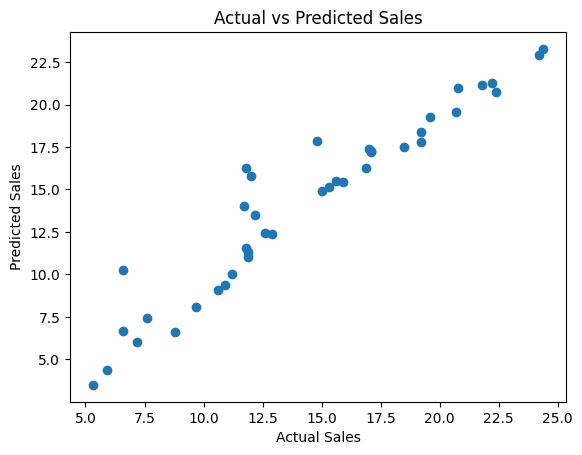

In [80]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()